# **Project: Stock Price Prediction**

**Objective**: Predict the future stock price of Apple Inc. based on its current closing price.

# **Algorithm Used**: Long Short-Term Memory (LSTM)

## ***Methodology***: Predict the stock market closing price (the last price at which a financial security is traded during a trading session) of Apple Inc. using the closing prices from the previous 60 days.

Le package pandas-datareader est un outil précieux pour les data scientists et les analystes financiers qui travaillent avec des données financières et économiques.

In [ ]:
!pip install --upgrade pandas-datareader

In [ ]:
import numpy as np
import math
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
from datetime import datetime
import pandas_datareader.data as web
import yfinance as yf

# **Download the historical stock price data of Apple Inc. (AAPL) from Yahoo Finance.

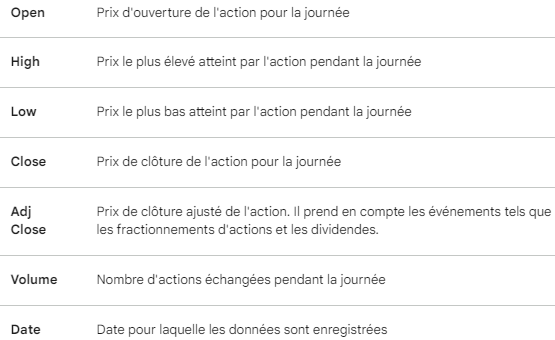

In [ ]:
# Get APPLE INC. stock market data using the ticker symbol AAPL from January 2012 to October 25, 2020.

# Download Apple stock price data (ticker symbol "AAPL") between the specified start and end dates
# using yfinance (a Python library/API for Yahoo Finance).
start = datetime(2012, 1, 12)
end = datetime(2020, 10, 25)
df = yf.download('AAPL', start=start, end=end)
df.head()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-12,15.081429,15.103571,14.955357,15.049643,12.741019,212587200
2012-01-13,14.989286,15.016071,14.952143,14.993214,12.693246,226021600
2012-01-17,15.150000,15.213929,15.105714,15.167857,12.841099,242897200
2012-01-18,15.248571,15.338214,15.225000,15.325357,12.974438,276791200
2012-01-19,15.362500,15.406071,15.232500,15.276786,12.933317,261738400


In [ ]:

df.shape

(2211, 6)

# Display the historical closing prices of Apple Inc..

# ** Data training**

In [ ]:
# Créer un nouveau DataFrame nommé data en filtrant le DataFrame original df pour n'inclure que la colonne "Close".
#filter(): méthode Pandas qui permet de sélectionner des colonnes en fonction de conditions spécifiques
data = df.filter(['Close'])

#dataframe to numpy array
dataset = data.values

# calculer la longueur de l'ensemble de données d'entraînement, qui représentera 80 % du total des données.
#math.ceil() arrondit la valeur de len(dataset) * 0.8 à l'entier supérieur le plus proche.
training_data_len = math.ceil(len(dataset)*.80)

In [ ]:
dataset.shape

(2211, 1)

Mettre à l'**échelle des données** numériques selon une plage commune. Cette étape est essentielle lors de l'entraînement car les différentes caractéristiques (colonnes) peuvent avoir des échelles différentes, ce qui peut affecter le processus d'apprentissage

In [ ]:
# Data Normalizing
# Normaliser les données de la BD dans l'intervalle [0,1]
scaler = MinMaxScaler(feature_range=(0,1)) #crée un objet MinMaxScaler nommé scaler avec une plage entre 0 et 1
scaled_data = scaler.fit_transform(dataset) #effectue le processus de normalisation proprement dit.

In [ ]:
#extraire l'ensemble de données d'entraînement à partir des données normalisées
#sélectioner toutes les lignes (: ) du tableau scaled_data du début (index 0) jusqu'à l'index training_data_len (exclu).
train_data = scaled_data[0:training_data_len]
print(train_data.shape)
# Split the data into input and output dataset (x_train, y_train)
x_train = []
y_train = []

#créer l'ensemble de données d'entraînement mis à échelle en extrayant des séquences de 60 jours consécutifs de prix de clôture normalisés
# 60 is coming form 60 days.
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60: i]) # x:une séquence d'entrée composée de 60 valeurs consécutives , #, 0 sélectionne uniquement la première colonne (index 0), qui correspond aux prix de clôture normalisés.
    y_train.append(train_data[i]) #y: le prix de clôture courant (du 60ème jou)

(1769, 1)


In [ ]:
print(len(x_train))
print(len(y_train))

1709
1709


In [ ]:
# Convert x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

Les réseaux de neurones à mémoire longue (LSTM) nécessitent des données d'entrée en trois dimensions pour capturer les relations temporelles entre les séquences

In [ ]:
# redimensionner les données sous une forme tridimensionnelle (nombre d'échantillons, nombre de pas de temps, nombre de fonctionnalités) la forme acceptée par LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# dim1:(au nombre d'échantillons (séquences),
# dim2: nombre d'étapes temporelles (jours) dans chaque séquence,
# dim3: aoute une dimension supplémentaire de taille 1 pour représenter le nombre de caractéristiques (prix de clôture normalisé).)

In [ ]:
x_train.shape

(1709, 60, 1)

# **Construire le modèle**
* Construisez le modèle LSTM pour avoir deux couches LSTM avec 50 neurones et deux couches denses, une avec 25 neurones et l'autre avec 1 neurone.

**units=50**: spécifie le nombre d'unités de mémoire interne dans la couche LSTM. Ici, 50 unités sont utilisées.

**return_sequences=True**: Indique que la couche LSTM doit renvoyer non seulement la sortie finale, mais aussi les sorties pour chaque étape temporelle de l'entrée. Cela permet à la deuxième couche LSTM d'accéder aux informations temporelles tout au long de la séquence.

**input_shape=(x_train.shape[1], 1):**  
*   **x_train.shape[1]**: Correspond au nombre d'étapes temporelles (jours) dans chaque séquence, récupéré de la forme de x_train.
*   **1**: Correspond au nombre de caractéristiques (prix de clôture normalisé) dans chaque étape temporelle.

In [ ]:
# Build LSTM model
model=Sequential()
model.add(LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1],1))) # (60,1)
model.add(LSTM(units=50,return_sequences=False)) # renvoyer juste la sortie finale de la séquence
model.add(Dense(25)) #activation: linear ; par defaut
model.add(Dense(1)) #Le neurone de sortie génère la prévision du prix de clôture normalisé pour l'étape temporelle suivante.

In [ ]:
#Compile the LSTM model
model.compile(optimizer='adam',loss='mean_squared_error') #l'erreur quadratique moyenne (MSE) est utilisée comme fonction de perte.
#La MSE calcule la moyenne des carrés des différences entre les prédictions et les valeurs réelles.

In [ ]:
# prompt: how to configure the eraly stopping configure

from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='loss', patience=100, mode='min', verbose=1)

history = model.fit(x_train, y_train, epochs=1000, batch_size=32, callbacks=[early_stopping])


Epoch 1/1000
54/54 [==============================] - 4s 9ms/step - loss: 2.5879e-05
Epoch 2/1000
54/54 [==============================] - 0s 8ms/step - loss: 1.8088e-05
Epoch 3/1000
54/54 [==============================] - 0s 8ms/step - loss: 2.0230e-05
Epoch 4/1000
54/54 [==============================] - 0s 8ms/step - loss: 2.5378e-05
Epoch 5/1000
54/54 [==============================] - 0s 8ms/step - loss: 1.9082e-05
Epoch 6/1000
54/54 [==============================] - 0s 8ms/step - loss: 1.8495e-05
Epoch 7/1000
54/54 [==============================] - 0s 8ms/step - loss: 1.9790e-05
Epoch 8/1000
54/54 [==============================] - 0s 8ms/step - loss: 2.0704e-05
Epoch 9/1000
54/54 [==============================] - 0s 8ms/step - loss: 1.8563e-05
Epoch 10/1000
54/54 [==============================] - 0s 8ms/step - loss: 2.0859e-05
Epoch 11/1000
54/54 [==============================] - 0s 8ms/step - loss: 1.8275e-05
Epoch 12/1000
54/54 [==============================] - 0s 8ms/s

# **Courbes d'apprentissage**

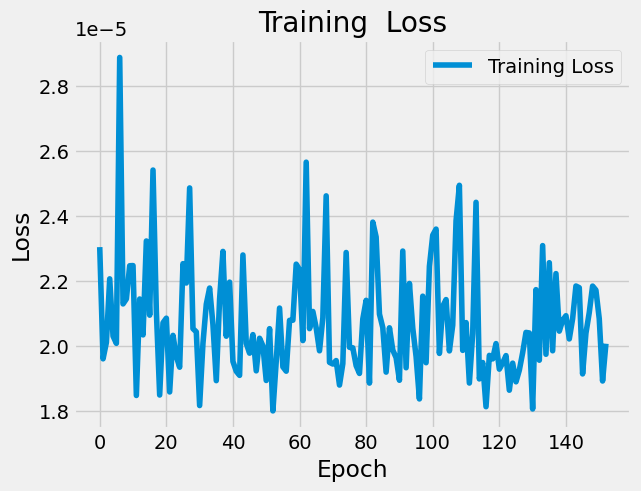

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training  Loss')
plt.legend()
plt.show()


# **Création de l'ensemble de données de test**

*   **training_data_len** : Correspond à la longueur de l'ensemble de données d'entraînement (80 % du jeu de données total).
*   **-60** : Soustrait 60 pour commencer l'extraction 60 jours après la fin de l'ensemble de données d'entraînement.
*   **:** sélectionne toutes les colonnes (: ) pour l'ensemble des lignes restantes dans scaled_data.




In [ ]:
# Extraire les données de test à partir des données normalisées
test_data = scaled_data[training_data_len-60:]
x_test = []
y_test = dataset[training_data_len:]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i])

# Convert the x_test set to a numpy array
x_test = np.array(x_test)

# Reshape the data into 3-dimensional form (no of samples, no of time steps, no of features) the shape accepted by LSTM
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# **Validation du modèls**

Prédiction des prix  et évaluation du modèle

In [ ]:
#générer des prédictions de prix de clôture normalisés sur la base des séquences d'entrée de test (x_test).
prediction = model.predict(x_test)
print(len(prediction))
# Les prix ont été normalisés à une plage de 0 à 1 avant l'entraînement du modèle.
#--> inverser la normalisation pour ramener les prédictions à l'échelle d'origine des prix de clôture réels.
#--> Il utilise les paramètres calculés lors de la normalisation initiale avec MinMaxScaler (valeurs minimales et maximales) pour inverser le processus de mise à l'échelle.
prediction = scaler.inverse_transform(prediction)

# calculer l'erreur quadratique moyenne (RMSE) pour évaluer la performance du modèle.
#Le MSE mesure la différence moyenne entre les prédictions du modèle (prediction) et les prix de clôture réels du jeu de test (y_test).
mse = np.sqrt( np.mean(prediction-y_test)**2)
print("MSE= ", mse)

14/14 [==============================] - 0s 5ms/step
442
MSE=  0.4789757793305686


# **Tests de données**
* Validation du modèle terminée avec une précision de prédiction acceptable.
Lancer les tests de données.

<ipython-input-54-d8e01ab0ccaf>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Prediction']=prediction # ajouter une nouvelle colonne nommée "Prediction" à l'ensemble de données de validation


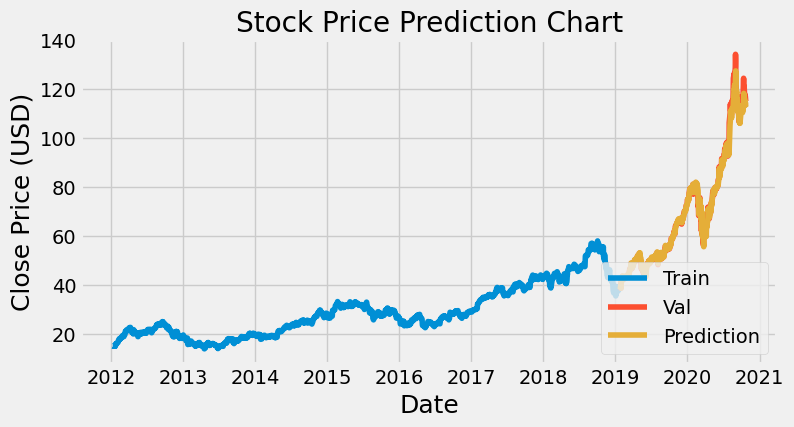

In [ ]:
# Création et affichage du graphique de prédiction
train=data[:training_data_len] # l'ensemble de données d'entraînement
valid=data[training_data_len:] # l'ensemble de données de validation
valid['Prediction']=prediction # ajouter une nouvelle colonne nommée "Prediction" à l'ensemble de données de validation

# Visualise the data
plt.figure(figsize=(8,4))
plt.title('Stock Price Prediction Chart')
plt.xlabel('Date',fontsize=18)
plt.ylabel('Close Price (USD)',fontsize=18)
plt.plot(train['Close']) #tracer la courbe des prix de clôture de l'ensemble de données d'entraînement
plt.plot(valid[['Close','Prediction']]) #trace deux courbes supplémentaires; les prix de clôture réels et les  prédictions de prix de clôture de l'ensemble de données de validation
plt.legend(['Train','Val','Prediction'],loc='lower right')
plt.show()

In [ ]:
# Afficher les prix réels (valides) et prévus
valid

,Close,Prediction
Date,,
2019-01-25,39.439999,38.296921
2019-01-28,39.075001,39.573093
2019-01-29,38.669998,39.091454
2019-01-30,41.312500,38.734032
2019-01-31,41.610001,41.454227
...,...,...
2020-10-19,115.980003,115.305954
2020-10-20,117.510002,113.323181
2020-10-21,116.870003,114.540031
